In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

from sklearn.decomposition import PCA

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import joblib

In [59]:
df =pd.read_csv(r"C:\Users\manis\OneDrive\Desktop\IOT unsupervised\data\IoT Sensor Anomaly Detection.csv")

In [60]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [62]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [63]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [64]:
df.shape

(10000, 14)

In [65]:
know_unique = ["TWF", "HDF", "PWF", "OSF", "RNF"]

In [66]:

for col in know_unique:
    print(col , df[col].unique())

TWF [0 1]
HDF [0 1]
PWF [0 1]
OSF [0 1]
RNF [0 1]


In [67]:
for col in know_unique:
    print(col, df[col].value_counts())

TWF TWF
0    9954
1      46
Name: count, dtype: int64
HDF HDF
0    9885
1     115
Name: count, dtype: int64
PWF PWF
0    9905
1      95
Name: count, dtype: int64
OSF OSF
0    9902
1      98
Name: count, dtype: int64
RNF RNF
0    9981
1      19
Name: count, dtype: int64


In [68]:
X = df.drop(columns=[
    "Machine failure",
    "TWF","HDF","PWF","OSF","RNF",
    "UDI","Product ID"
])

In [69]:
X.head(1)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0


In [70]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 468.9+ KB


In [71]:
X["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

In [72]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

In [73]:
num_pipeline = Pipeline([("scaler", StandardScaler())])
cat_pipeline = Pipeline([("ordencoder", OrdinalEncoder(categories=[["L","M","H"]]))])

In [74]:
preprocessor = ColumnTransformer([("num", num_pipeline, num_cols), ("cat", cat_pipeline, cat_cols)])

## Elbow Method To Find Optimum Number Of K

In [75]:
wcss = []
for k in range(1,7):
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", KMeans(n_clusters= k, random_state=42))])
    X_KMeans = pipeline.fit(X)
    wcss.append(pipeline.named_steps["model"].inertia_)
    

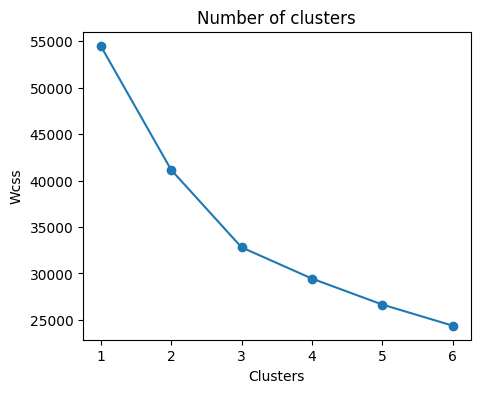

In [76]:
plt.figure(figsize= (5,4))
plt.plot(range(1,7), wcss, marker= "o")
plt.xlabel("Clusters")
plt.ylabel("Wcss")
plt.title("Number of clusters")
plt.show()

## Elbow Method Interpretation

The Elbow Method is used to determine the optimal number of clusters (`k`) for the K-Means algorithm by plotting the **Within-Cluster Sum of Squares (WCSS)** against different values of `k`.

### Observation

- WCSS decreases as the number of clusters increases because data points become closer to their assigned cluster centroids.
- The curve shows a **sharp decrease** from **k = 1** to **k = 3**.
- After **k = 3**, the reduction in WCSS becomes much smaller, indicating diminishing returns from adding more clusters.

### Conclusion

The **elbow point** is observed at **k = 3**. Therefore, the optimal number of clusters for this dataset is **3**.

This indicates that dividing the data into three clusters provides a good balance between minimizing WCSS and avoiding unnecessary model complexity.

**Optimal Number of Clusters:** **3**

# Applyed K means clustring with 3 clusters

In [77]:
pipeline = Pipeline([ ("preprocessor", preprocessor),("model", KMeans(n_clusters=3, random_state = 42, init = "k-means++"))])
                                                                
X_KMeans1 = pipeline.fit(X)

In [78]:
from sklearn.metrics import silhouette_score

labels = pipeline.named_steps["model"].labels_

X_processed = pipeline.named_steps["preprocessor"].transform(X)

score = silhouette_score(X_processed, labels)

print("Silhouette Score:", score)


Silhouette Score: 0.2348033350252458


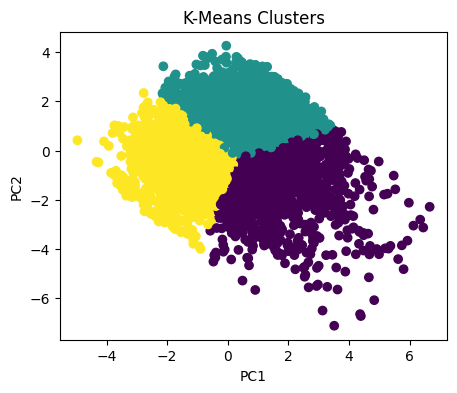

In [79]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_processed = pipeline.named_steps["preprocessor"].transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(5,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()

In [80]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.pipeline import Pipeline

X_transformed = preprocessor.fit_transform(X)

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = agg.fit_predict(X_transformed)

In [81]:
score = silhouette_score(X_transformed, labels)

print(score)

0.18570225578611935


In [ ]:
from sklearn.cluster import DBSCAN

for eps in [0.2, 0.4, 0.6, 0.8, 1.0]:

    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_transformed)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print("="*60)
    print(f"eps = {eps}")
    print("Clusters:", n_clusters)
    print("Noise:", n_noise)
    print("="*60)

eps = 0.2
Clusters: 2
Noise: 9990
eps = 0.4
Clusters: 114
Noise: 4392
eps = 0.6
Clusters: 25
Noise: 828
eps = 0.8
Clusters: 6
Noise: 221
eps = 1.0
Clusters: 4
Noise: 97


## Model Comparison

Three clustering algorithms were evaluated on the preprocessed IoT sensor dataset: **K-Means**, **Agglomerative Clustering**, and **DBSCAN**.

- **K-Means** achieved a **Silhouette Score of 0.2348**, which was the highest among the evaluated models.
- **Agglomerative Clustering** achieved a **Silhouette Score of 0.1857**, indicating weaker cluster separation than K-Means.
- **DBSCAN** was evaluated using different `eps` values. Although `eps = 0.2` produced a high Silhouette Score, it classified **9,990 out of 10,000 observations as noise**, making the result unreliable. For larger `eps` values, the clustering quality remained lower than K-Means.

## Conclusion

Based on the comparison, **K-Means** was selected as the final clustering algorithm because it provided the best balance between cluster cohesion and separation on the IoT sensor dataset. The results indicate that the dataset contains moderately distinguishable operating patterns, while density-based clustering was not well suited for this data.

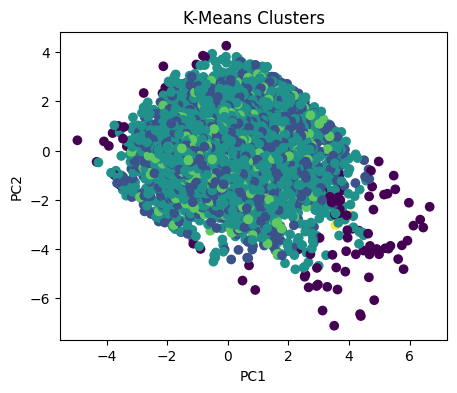

In [83]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_processed = pipeline.named_steps["preprocessor"].transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(5,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()

In [84]:
df["Cluster"] = pipeline.named_steps["model"].labels_

df.groupby("Cluster").mean(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
Cluster,,,,,,,,,,,,
0,5225.829068,300.131965,310.111347,1795.769676,26.619845,109.399324,0.022211,0.005794,0.000000,0.014969,0.000000,0.001449
1,5623.020881,301.718360,311.242602,1469.207283,43.691953,110.244207,0.052457,0.005348,0.029284,0.008403,0.012732,0.002801
2,4273.039730,298.257871,308.736957,1474.049225,43.268641,104.951274,0.021739,0.003248,0.000000,0.007746,0.011994,0.001249


In [85]:
pd.crosstab(df["Cluster"], df["Type"])

Type,H,L,M
Cluster,,,
0,204,1264,603
1,353,2374,1200
2,446,2362,1194


In [86]:
pd.crosstab(df["Cluster"], df["TWF"])
pd.crosstab(df["Cluster"], df["HDF"])
pd.crosstab(df["Cluster"], df["PWF"])
pd.crosstab(df["Cluster"], df["OSF"])
pd.crosstab(df["Cluster"], df["RNF"])

RNF,0,1
Cluster,,
0,2068,3
1,3916,11
2,3997,5


In [87]:
pd.crosstab(df["Cluster"], df["RNF"], normalize="index") * 100

RNF,0,1
Cluster,,
0,99.855142,0.144858
1,99.719888,0.280112
2,99.875062,0.124938


### Random Failure (RNF) Analysis

The percentage of Random Failures (RNF) was analyzed across the three clusters.

- Cluster 0 recorded a random failure rate of **0.145%**.
- Cluster 1 recorded the highest random failure rate of **0.280%**.
- Cluster 2 recorded the lowest random failure rate of **0.125%**.

Although Cluster 1 shows a slightly higher rate of random failures, the overall occurrence of RNF is less than **0.3%** across all clusters. Therefore, Random Failure is not a significant factor differentiating the machine operating groups.

In [88]:
pd.crosstab(df["Cluster"], df["TWF"], normalize="index") * 100
pd.crosstab(df["Cluster"], df["HDF"], normalize="index") * 100
pd.crosstab(df["Cluster"], df["PWF"], normalize="index") * 100
pd.crosstab(df["Cluster"], df["OSF"], normalize="index") * 100
pd.crosstab(df["Cluster"], df["Machine failure"], normalize="index") * 100

Machine failure,0,1
Cluster,,
0,97.778851,2.221149
1,94.754265,5.245735
2,97.826087,2.173913


# Conclusion

This project applied **unsupervised machine learning** to analyze IoT sensor data collected from industrial machines. The objective was to discover hidden operating patterns without using the machine failure labels during training.

The dataset was preprocessed using **ColumnTransformer** and **Pipeline**, where numerical features were standardized using **StandardScaler** and the categorical feature was encoded using **OrdinalEncoder**.

Three clustering algorithms were evaluated:

- **K-Means**
- **Agglomerative Clustering**
- **DBSCAN**

The models were compared using the **Silhouette Score**.

- **K-Means:** 0.2348
- **Agglomerative Clustering:** 0.1857
- **DBSCAN:** Produced unstable clusters and a lower practical Silhouette Score due to a large number of noise points.

Based on the evaluation, **K-Means** was selected as the final clustering model because it achieved the best overall cluster separation.

The discovered clusters were visualized using **Principal Component Analysis (PCA)**, which provided a two-dimensional representation of the machine operating groups.

Finally, the generated clusters were compared with the actual **Machine Failure** labels (used only for analysis). The results showed that **Cluster 1** had the highest machine failure rate (**5.25%**), while **Clusters 0 and 2** had failure rates of approximately **2.2%**. This indicates that the operating conditions represented by Cluster 1 are associated with a higher risk of machine failure.

## Business Impact

- Identified three distinct machine operating patterns from sensor data.
- Selected the best clustering algorithm through quantitative evaluation.
- Detected a cluster associated with a higher machine failure rate.
- Demonstrated how unsupervised learning can support predictive maintenance and prioritize machines for inspection without requiring labeled training data.